Elbow: tensor([[1.3125, 0.0051, 0.7262]], device='cuda:0')
Wrist: tensor([[2., 0., 0.]], device='cuda:0')
FK Reconstructed Elbow: tensor([[1.3125, 0.0051, 0.7262]], device='cuda:0')
FK Reconstructed Wrist: tensor([[2.0000e+00, 9.3598e-08, 5.9605e-08]], device='cuda:0')


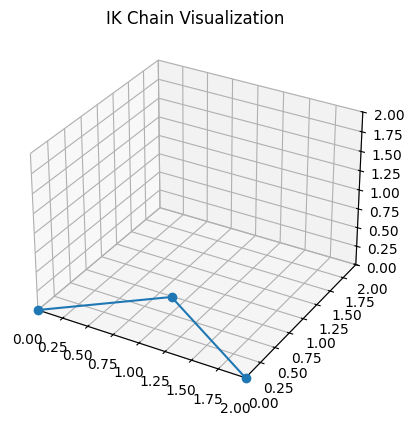

In [45]:
import os
os.chdir("..")

from pose_encoder.ik_two_bone import IKChain2Bone
import torch
import math
from utils.utils import *

device = get_device()

chain = IKChain2Bone(l1=1.5, l2=1.0, device=device,
                     bone1_forward_dir=torch.tensor([0.0, -0.9999752044677734, 0.007038275245577097], device=device),
                     bone1_up_dir=torch.tensor([0.0, 0.007038275711238384, 0.9999752640724182], device=device),
                     bone2_forward_dir=torch.tensor([0.0, -0.996783435344696, -0.0801420658826828], device=device),
                     bone2_up_dir=torch.tensor([0.0, 0.0801420658826828, -0.996783435344696], device=device))

start = torch.tensor([0.0, 0.0, 0.0], device=device).unsqueeze(0)
target = torch.tensor([2, 0.0, 0.0], device=device).unsqueeze(0)
swivel = torch.tensor(math.radians(0), device=device).unsqueeze(0)

rot1, rot2, joint1, joint2 = chain.ik_to_fk(start, target, swivel)

print("Elbow:", joint1)
print("Wrist:", joint2)
fk_joint1, fk_joint2 = chain.fk_positions(start, rot1, rot2)
print("FK Reconstructed Elbow:", fk_joint1)
print("FK Reconstructed Wrist:", fk_joint2)

import matplotlib.pyplot as plt

# Forward pass to get joint positions
fk_joint1, fk_joint2 = chain.fk_positions(start, rot1, rot2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

start_cpu = start.squeeze(0).cpu()
fk_joint1_cpu = fk_joint1.squeeze(0).cpu()
fk_joint2_cpu = fk_joint2.squeeze(0).cpu()

ax.plot(
    [start_cpu[0], fk_joint1_cpu[0], fk_joint2_cpu[0]],
    [start_cpu[1], fk_joint1_cpu[1], fk_joint2_cpu[1]],
    [start_cpu[2], fk_joint1_cpu[2], fk_joint2_cpu[2]],
    marker='o'
)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(0, 2)
ax.set_title("IK Chain Visualization")
plt.show()
